In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


This script will,
1. Load already cleaned data.( cleaned and saved individual target files as CSVs)

2. Selecting relevant columns

3. Classifying IC50 into activity classes

4. Saving the labeled data

5. Generating summary statistics

6. Creating and saving bar plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec



In [ ]:
# Path to the cleaned files
input_path = '/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/cleaned-original-data'
output_path = '/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data'

# Dictionary of target names and their corresponding CSV filenames
target_files = {
    '5-HT6': 'cleaned_5-HT6_ic50.csv',
    'ache': 'cleaned_ache_ic50.csv',
    'bace1': 'cleaned_bace1_ic50.csv',
    'buche': 'cleaned_buche_ic50.csv',
    #'esr1': 'cleaned_esr1_ic50.csv',
    #'3beta': 'cleaned_GSK-3beta_ic50.csv',
    'mao-b': 'cleaned_mao-b_ic50.csv'
}

# Dictionary to hold processed DataFrames
processed_dfs = {}



In [ ]:
# Step 1: Load files and keep relevant columns
columns_to_keep = ['molecule_chembl_id', 'canonical_smiles', 'IC50_nM', 'pIC50', 'target_chembl_id']

In [ ]:
for target, file_name in target_files.items():
    path = os.path.join(input_path, file_name)
    df = pd.read_csv(path)
    df = df[columns_to_keep]
    processed_dfs[target] = df
    print(f"{target} - Loaded and trimmed to relevant columns. Total entries: {len(df)}")

5-HT6 - Loaded and trimmed to relevant columns. Total entries: 941
ache - Loaded and trimmed to relevant columns. Total entries: 6630
bace1 - Loaded and trimmed to relevant columns. Total entries: 9799
buche - Loaded and trimmed to relevant columns. Total entries: 3903
mao-b - Loaded and trimmed to relevant columns. Total entries: 4840


 **Activity Thresholds:**

To classify compounds as active or inactive, pIC50 threshold of 7.0 , which corresponds to an IC50 of 100 nM was used. This is a commonly accepted cutoff in medicinal chemistry to define potent bioactivity. Compounds with pIC50 ≥ 7 (i.e., IC50 ≤ 100 nM) are considered active, as they exhibit strong binding affinity and are more likely to be pharmacologically relevant. Those with pIC50 < 7 are categorized as inactive, representing weaker or negligible activity.

This binary classification simplifies modeling and allows for clearer performance evaluation in structure–activity relationship (SAR) studies. Such binary classification is ideal for training machine learning models for classification, and it simplifies downstream tasks like model evaluation.

In [ ]:
# Step 2: Classify bioactivity

# Define binary classification function based on pIC50
def classify_activity_binary(pIC50):
    return 'active' if pIC50 >= 7 else 'inactive'

In [ ]:
for target, df in processed_dfs.items():
    df['bioactivity_class'] = df['pIC50'].apply(classify_activity_binary)
    processed_dfs[target] = df
    print(f"{target} - Bioactivity classification completed.")

5-HT6 - Bioactivity classification completed.
ache - Bioactivity classification completed.
bace1 - Bioactivity classification completed.
buche - Bioactivity classification completed.
mao-b - Bioactivity classification completed.


In [ ]:
# Step 3: Save labeled datasets
for target, df in processed_dfs.items():
    save_path = os.path.join(output_path, f"{target}_cleaned_labeled.csv")
    df.to_csv(save_path, index=False)
    print(f"{target} - Labeled dataset saved to {save_path}")

5-HT6 - Labeled dataset saved to /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/5-HT6_cleaned_labeled.csv
ache - Labeled dataset saved to /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/ache_cleaned_labeled.csv
bace1 - Labeled dataset saved to /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/bace1_cleaned_labeled.csv
buche - Labeled dataset saved to /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/buche_cleaned_labeled.csv
mao-b - Labeled dataset saved to /content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/mao-b_cleaned_labeled.csv


In [ ]:
# Step 4: Create summary table and plots
summary_data = []

for target, df in processed_dfs.items():
    counts = df['bioactivity_class'].value_counts()
    total = len(df)
    active = counts.get('active', 0)
    intermediate = counts.get('intermediate', 0)
    inactive = counts.get('inactive', 0)

    summary_data.append({
        'Target': target,
        'Total': total,
        'Active': active,
        'Inactive': inactive
    })




In [ ]:
# Save summary table
summary_df = pd.DataFrame(summary_data)
summary_path = os.path.join(output_path, 'target_summary.csv')
summary_df.to_csv(summary_path, index=False)

print("\nSummary of all targets:")
print(summary_df)


Summary of all targets:
  Target  Total  Active  Inactive
0  5-HT6    941     470       471
1   ache   6630    1959      4671
2  bace1   9799    4456      5343
3  buche   3903    1066      2837
4  mao-b   4840    1259      3581


# **Visualize Activity Class Distribution**

/tmp/ipython-input-2662086309.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


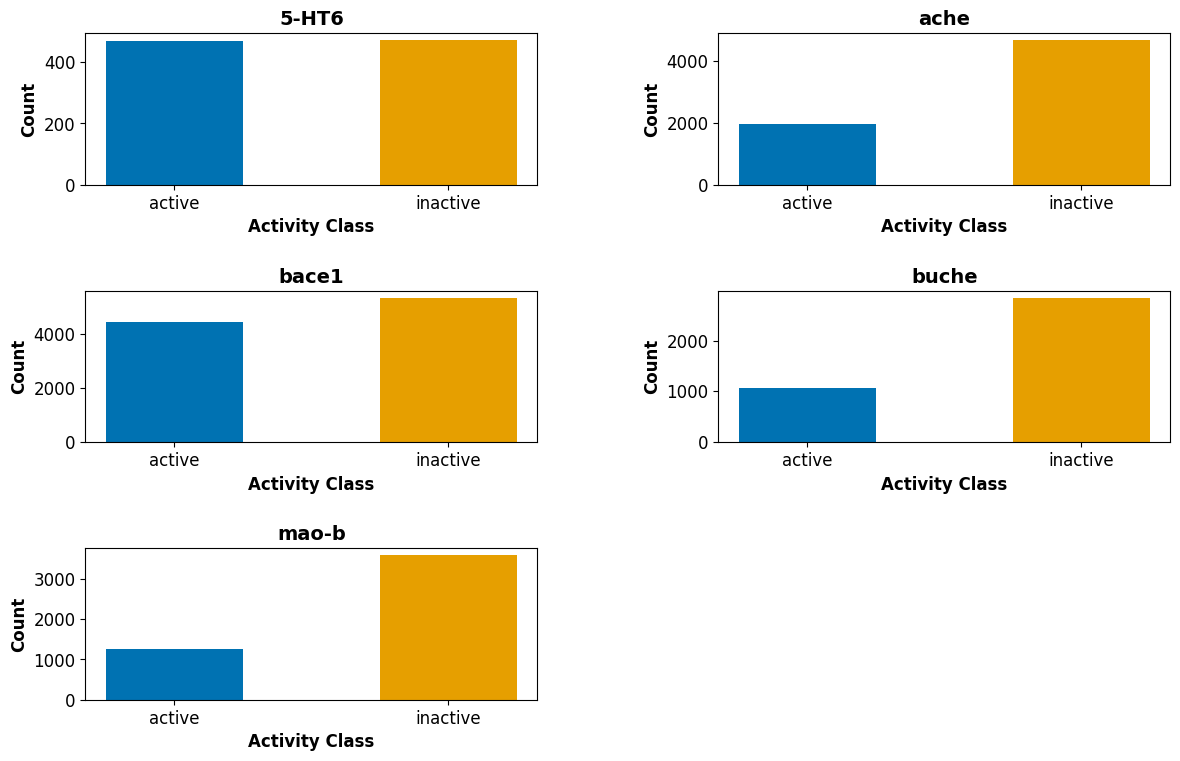

In [ ]:


fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.7, wspace=0.4)


# Loop through each file
for idx, (target, filename) in enumerate(target_files.items()):
    filepath = os.path.join(input_path, filename)
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row, col])

    # Load data
    df = pd.read_csv(filepath)

    # Step 1: Keep only relevant columns
    df = df[['molecule_chembl_id', 'canonical_smiles', 'IC50_nM', 'pIC50', 'target_chembl_id']]

    # Step 2: Classify based on IC50
    df['activity_class'] = df['pIC50'].apply(classify_activity_binary)

    # Step 3: Plot activity class distribution
    class_counts = df['activity_class'].value_counts()
    class_counts = df['activity_class'].value_counts().reindex(['active', 'inactive'], fill_value=0)
    ax.bar(class_counts.index, class_counts.values, color=['#0072B2', '#E69F00'], width=0.5)
    ax.set_title(f"{target}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Count", fontsize=12,fontweight='bold')
    ax.set_xlabel("Activity Class", fontsize=12,fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)

# Remove the unused subplot (8th one)

if len(target_files) < 8 and len(fig.axes) == 8:
    fig.delaxes(fig.axes[-1])

# Final layout
fig.tight_layout(rect=[0, 0, 1, 0.95])
#plt.suptitle("Bioactivity Class Distribution Across AD Targets", fontsize=20, y=1.05)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/combined_activity_class_plot.png", bbox_inches='tight')
plt.show()

# **Visualize Data Availability for different AD Targets**

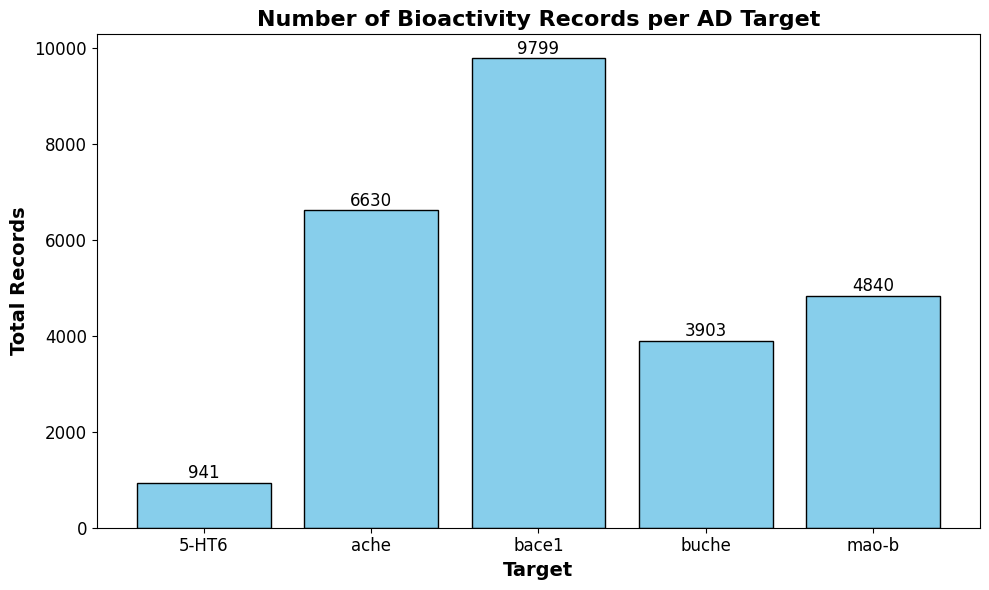

In [ ]:

# Count the number of records per target
target_names = []
record_counts = []

for target, df in processed_dfs.items():
    target_names.append(target)
    record_counts.append(len(df))


# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(target_names, record_counts, color='skyblue', edgecolor='black')

# Styling
plt.title("Number of Bioactivity Records per AD Target", fontsize=16, fontweight='bold')
plt.xlabel("Target", fontsize=14, fontweight='bold')
plt.ylabel("Total Records", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5, str(height),
             ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/processed-data/activity-labeled-data/target_record_comparison.png", dpi=300)
